In [1]:
%matplotlib inline 

In [2]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_moving_source_like_czm_subrayleigh" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata


   ┌────────────────────────────────────────────────────────────────────────────────────┐
   │                                                                                    │
   │   Salvus update available!                                                         │
   │                                                                                    │
   │   2025.1.2 → 2026.5.0                                                              │
   │                                                                                    │
   │   See https://docs.mondaic.com/updates/changelog                                   │
   │   for a list of changes and new features.                                          │
   │                                                                                    │
   │   To upgrade, please first make sure that your python environment is up to date:   │
   │                                                                                    │
   │   ht

In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-06-10 16:07:40,462] INFO: Loading project from simulation_wavefield_moving_source_like_czm_subrayleigh.


In [4]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).

x_min, x_max = 0.0, 400.0

# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)
 
max_frequency = np.percentile([vp[0], vp[1], vp[2]], 95) # set this as the 95th percentile of the expected frequency content
print(f"Max frequency for meshing: {max_frequency:.1f} Hz")
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")


Max frequency for meshing: 328.8 Hz
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [13]:
# Moving source setup: all source locations in ONE event (not one event per location).
lambda_min = min(vs[vs > 0]) / max_frequency
print(f"Minimum wavelength to resolve: {lambda_min:.2f} m")

# Have about 5 to 10 sources per wavelength for a physical crack representation.
steps = 0.5  # m spacing
x_positions = np.arange(30.0, 270.0, 0.5)


# Keep source in snow layer.
y_source = 2.625

# Sub-Rayleigh rupture speed target for source delays.
target_vprop = 90  # m/s (slower than vs=150 m/s for subrayleigh)
dx = x_positions[1] - x_positions[0]
dt_src = dx / target_vprop
source_delays = np.arange(len(x_positions)) * dt_src

source_strengths_xy = []
source_strengths_yy = []
srcs = []

for i, x_pos in enumerate(x_positions):
    src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
        x=float(x_pos),
        y=y_source,
        mxx=0.0,
        myy=-1.54e+01,
        mxy=0.0,
    )
    srcs.append(src)
    source_strengths_xy.append(0.0)
    source_strengths_yy.append(-1.54e+01)

moving_source_event_name = "event_wavefield_output_all_sources"

# Re-runnable pattern: replace existing event explicitly, then add the updated one.
if moving_source_event_name in p.events.list():
    p.events.delete(event_name=moving_source_event_name)

p.add_to_project(sn.Event(event_name=moving_source_event_name, sources=srcs))

print(f"Added event '{moving_source_event_name}' with {len(srcs)} sources.")
print(f"Source delays span {source_delays[0]:.2f}s to {source_delays[-1]:.2f}s.")
print(f"Initial source magnitudes: mxy={source_strengths_xy[0]:.2f}, myy={source_strengths_yy[0]:.2f}")
if len(source_strengths_xy) > 1:
    print(f"First crack source magnitudes: mxy={source_strengths_xy[1]:.2f}, myy={source_strengths_yy[1]:.2f}")
    print(f"Last crack source magnitudes: mxy={source_strengths_xy[-1]:.2f}, myy={source_strengths_yy[-1]:.2f}")

Minimum wavelength to resolve: 0.46 m
Added event 'event_wavefield_output_all_sources' with 480 sources.
Source delays span 0.00s to 2.66s.
Initial source magnitudes: mxy=0.00, myy=-15.40
First crack source magnitudes: mxy=0.00, myy=-15.40
Last crack source magnitudes: mxy=0.00, myy=-15.40


In [14]:
p.viz.nb.simulation_setup(
    simulation_configuration="sim_2d_layered_moving_source_all", events=p.events.list()
)

In [15]:
# raw coordinates of all element corners (shapes are elements x nodes_per_element x dimensions)
# For a 2D quad mesh, this has 4 nodes per element.
element_nodes = mesh_3layer.get_element_nodes()

#  minimum and maximum x coordinate for every individual element
el_x_min = element_nodes[:, :, 0].min(axis=1)
el_x_max = element_nodes[:, :, 0].max(axis=1)

# stimate of the physical size (width) of your elements along thex  axis
element_widths = el_x_max - el_x_min
avg_element_width = element_widths.mean()

print("--- NUMERICAL DISCRETIZATION EVALUATION ---")
print(f"Your source spacing (steps) : {steps} meters")
print(f"Average element width (dx)  : {avg_element_width:.3f} meters")

# 4. Evaluate the source density vs grid resolution
sources_per_element = avg_element_width / steps
print(f"Approximate sources landing inside a single element: {sources_per_element:.1f}")

if sources_per_element > 1.0:
    print("\n RESULT: DEFINITE SPATIAL DISCRETIZATION BLENDING!")
    print(f"You have roughly {sources_per_element:.1f} sources crowded inside each element.")
    print("Because the numerical grid is physically too coarse to tell them apart,")
    print("Salvus discretizes them onto the same local basis functions, causing them to overlap.")
else:
    print("\n RESULT: GRID IS FINE ENOUGH.")
    print("Each source point has its own unique element or local node support.")
    print("The overlap is purely wave physics (Huygens' constructive interference).")

--- NUMERICAL DISCRETIZATION EVALUATION ---
Your source spacing (steps) : 0.5 meters
Average element width (dx)  : 0.228 meters
Approximate sources landing inside a single element: 0.5

 RESULT: GRID IS FINE ENOUGH.
Each source point has its own unique element or local node support.
The overlap is purely wave physics (Huygens' constructive interference).


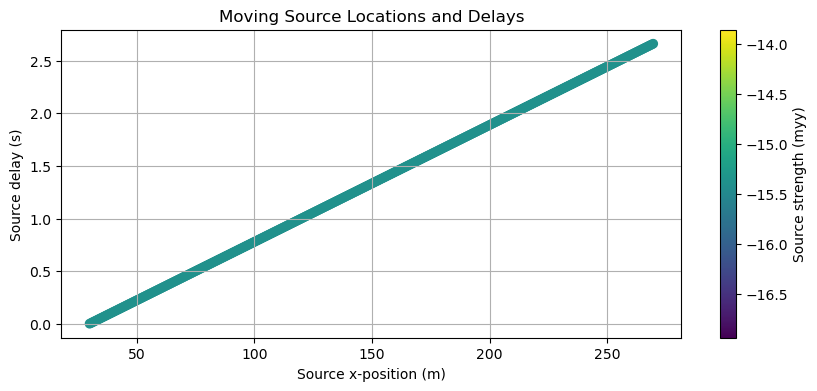


Sample of source time delays:
  Source at x=30.0 m has delay 0.000 s and strength myy=-15.40
  Source at x=78.0 m has delay 0.533 s and strength myy=-15.40
  Source at x=126.0 m has delay 1.067 s and strength myy=-15.40
  Source at x=174.0 m has delay 1.600 s and strength myy=-15.40
  Source at x=222.0 m has delay 2.133 s and strength myy=-15.40
delay between subsequent sources: 0.006 s (targeting rupture speed of 90 m/s)


In [16]:
# Plotting the source locations vs delays
fig = plt.figure(figsize=(10, 4))
plt.scatter(x_positions, source_delays, c=source_strengths_yy, cmap="viridis", marker="o")
plt.colorbar(label="Source strength (myy)")
plt.title("Moving Source Locations and Delays")
plt.xlabel("Source x-position (m)")
plt.ylabel("Source delay (s)")
plt.grid()
display(fig)
plt.close(fig)

# Also printing source time delays
print("\nSample of source time delays:")
for i in range(0, len(source_delays), max(1, len(source_delays) // 5)):  # print 5 evenly spaced sources
    print(f"  Source at x={x_positions[i]:.1f} m has delay {source_delays[i]:.3f} s and strength myy={source_strengths_yy[i]:.2f}")
print(f"delay between subsequent sources: {dt_src:.3f} s (targeting rupture speed of {target_vprop} m/s)")

In [ ]:
# One simulation configuration for the one-event moving-source setup.
moving_source_simulation_name = "sim_2d_layered_moving_source_all"
forced_solver_dt = 0.00001 # to try and force salvus to use a smaller internal timestep in the solver 
# # maximum delay accounting for simulation time needed 
# max_delay = float(source_delays[-1])
# needed_end_time = 0.3 + max_delay + 2.0
p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name=moving_source_simulation_name,
        unstructured_mesh=mesh_3layer,
        event_configuration=sn.EventConfiguration(
            # Dummy STF at config level; replaced per source below.
            wavelet=sn.simple_config.stf.Delta(),
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=-0.3,
                end_time_in_seconds=3.0,
                time_step_in_seconds=forced_solver_dt,
            ),
        ),
    ),
    overwrite=True,
)

# Use the waveform template API instead of get_input_files().  avoids  event-output validation while givingeditable waveform template
input_file = p.simulations.get_simulation_template(
    moving_source_simulation_name,
    moving_source_event_name,
)

# Seed the template with the actual sources from the event.
input_file.add_sources(srcs)

if len(input_file.physics.wave_equation.point_source) != len(source_delays):
    raise ValueError(
        f"Mismatch between input-file sources ({len(input_file.physics.wave_equation.point_source)}) and delays ({len(source_delays)})."
    )

# Rebuild and overwrite the list to force Salvus backend serialization
updated_point_sources = []

for i, src in enumerate(input_file.physics.wave_equation.point_source):
    # Dynamically bind the correct center frequency and independent delayed time shift
    src.source_time_function = sn.simple_config.stf.Ricker(
        center_frequency=10,
        time_shift_in_seconds=0.3 + float(source_delays[i]),
    )
    updated_point_sources.append(src)

# Overwriting the top-level property directly forces the Mondaic/Salvus data layer 
# to flag the array as "dirty" and write all 2,400 updates out to disk.
input_file.physics.wave_equation.point_source = updated_point_sources

# Safely call file-save if exposed by your specific Salvus API version wrapper
if hasattr(input_file, "save"):
    input_file.save()


# Remove point-output from this volume-only run.
del input_file.output.point_data

# Request volume output once for the combined run.
input_file.output.volume_data = {
    "filename": "volume_data_output.h5",
    "format": "hdf5",
    "fields": ["velocity", "displacement"],
    "sampling_interval_in_time_steps": 50,
}
input_file.validate()

print(f"Prepared '{moving_source_simulation_name}' for event '{moving_source_event_name}'.")
print(f"Assigned and successfully serialized {len(source_delays)} delayed wavelets in one event structure.")

[2026-06-10 15:20:42,442] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!
Prepared 'sim_2d_layered_moving_source_all' for event 'event_wavefield_output_all_sources'.
Assigned and successfully serialized 480 delayed wavelets in one event structure.


In [9]:

# Verification cell: confirm delays are attached and ordered correctly

ps = input_file.physics.wave_equation.point_source

print(f"Sources in input_file: {len(ps)}")
print(f"Expected: {len(source_delays)}\n")

# Check first, middle, last
for idx in [0, len(ps)//2, len(ps)-1]:
    src_if  = ps[idx]
    x_if    = src_if.location[0]         # x position from input_file
    t_if    = src_if.source_time_function.time_shift_in_seconds
    x_orig  = float(x_positions[idx])    # x position from your array
    t_orig  = 0.3 + source_delays[idx]   # expected time shift

    match_x = np.isclose(x_if, x_orig, atol=1e-6)
    match_t = np.isclose(t_if, t_orig,  atol=1e-6)

    print(f"Source {idx:4d}:")
    print(f"  x:       input_file={x_if:.4f}  expected={x_orig:.4f}  {'✓' if match_x else '✗ MISMATCH'}")
    print(f"  t_shift: input_file={t_if:.4f}  expected={t_orig:.4f}  {'✓' if match_t else '✗ MISMATCH'}")
    print()

# Full monotonicity check
t_shifts_if = [s.source_time_function.time_shift_in_seconds 
               for s in ps]
diffs = np.diff(t_shifts_if)
print(f"Time shifts monotonically increasing: {np.all(diffs > 0)}")
print(f"Expected dt between sources: {dt_src*1000:.4f} ms")
print(f"Actual  dt range: {diffs.min()*1000:.4f} – {diffs.max()*1000:.4f} ms")

Sources in input_file: 480
Expected: 480

Source    0:
  x:       input_file=30.0000  expected=30.0000  ✓
  t_shift: input_file=0.3000  expected=0.3000  ✓

Source  240:
  x:       input_file=150.0000  expected=150.0000  ✓
  t_shift: input_file=1.6333  expected=1.6333  ✓

Source  479:
  x:       input_file=269.5000  expected=269.5000  ✓
  t_shift: input_file=2.9611  expected=2.9611  ✓

Time shifts monotonically increasing: True
Expected dt between sources: 5.5556 ms
Actual  dt range: 5.5556 – 5.5556 ms


In [168]:
# Launch one combined simulation containing all delayed source wavelets in one event.
check_license_server_reachable()
print(f"Submitting combined moving-source run on site='{SALVUS_FLOW_SITE_NAME}' with ranks={RANKS_PER_JOB}")

# Write run outputs into the project directory.
moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
moving_source_job = sn.api.run(
    input_file=input_file,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    get_all=True,
    overwrite=True,
 )

print(f"Run finished. Output folder: {moving_source_output_folder}")

Submitting combined moving-source run on site='salome_remote_2' with ranks=4
SalvusJob `job_2606101145167239_a727c77b8d` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/330000 [00:00<?, ?it/s]

* Downloaded 44.7 GB of results to `simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources`.
* Total run time: 2031.62 seconds.
* Pure simulation time: 1917.95 seconds.
Run finished. Output folder: simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources


In [ ]:
import h5py
import numpy as np

hdf5_path = "simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources/volume_data_output.h5"

with h5py.File(hdf5_path, "r") as f:
    # Load displacement data (shape: 6601, 14208, 2, 25)
    displacement = f["volume"]["displacement"][:]

    # Check variability across time steps for a single node and source
    node_idx = 0  # Pick a node
    source_idx = 0  # Pick a source
    time_series = displacement[:, node_idx, 0, source_idx]  # x-component for node 0, source 0

    print("Time series for node 0, source 0, x-component:")
    print("Min:", time_series.min(), "Max:", time_series.max(), "Mean:", time_series.mean())

    # Check if all values are the same (indicates a problem)
    if np.all(time_series == time_series[0]):
        print("All time steps are identical! Simulation may be the issue.")
    else:
        print("Time series varies across time steps. Simulation is likely fine.")

    # Check variability across sources for a single time step and node
    time_idx = 0  # Pick a time step
    source_series = displacement[time_idx, node_idx, 0, :]  # x-component for node 0, all sources

    print("\nSource series for time 0, node 0, x-component:")
    print("Min:", source_series.min(), "Max:", source_series.max(), "Mean:", source_series.mean())

    if np.all(source_series == source_series[0]):
        print(" All sources are identical! Simulation may be the issue.")
    else:
        print(" Source series varies across sources. Simulation is likely fine.")

Time series for node 0, source 0, x-component:
Min: -8.455603e-07 Max: 9.877568e-07 Mean: -7.850561e-11
✅ Time series varies across time steps. Simulation is likely fine.

Source series for time 0, node 0, x-component:
Min: 0.0 Max: 0.0 Mean: 0.0
⚠️ All sources are identical! Simulation may be the issue.


In [10]:


vol_file = "simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources/volume_data_output.h5"

# Load the wavefield
dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

print("WavefieldOutput data shape:", dis_wo.data.shape)
print("WavefieldOutput time steps:", dis_wo.data.shape[0])
print("WavefieldOutput nodes:", dis_wo.data.shape[1])
print("WavefieldOutput components:", dis_wo.data.shape[2:])

# Check variability in the extracted data
time_series_wo = dis_wo.data[:, 0, 0, 0]  # Time series for node 0, first component, first source

print("\nTime series from WavefieldOutput for node 0, first component, first source:")
print("Min:", time_series_wo.min(), "Max:", time_series_wo.max(), "Mean:", time_series_wo.mean())

if np.all(time_series_wo == time_series_wo[0]):
    print(" All time steps are identical in WavefieldOutput! Extraction may be the issue.")
else:
    print(" Time series varies in WavefieldOutput. Extraction is likely fine.")

WavefieldOutput data shape: (6601, 14208, 2, 25)
WavefieldOutput time steps: 6601
WavefieldOutput nodes: 14208
WavefieldOutput components: (2, 25)

Time series from WavefieldOutput for node 0, first component, first source:
Min: -8.455603e-07 Max: 9.877568e-07 Mean: -7.850561e-11
 Time series varies in WavefieldOutput. Extraction is likely fine.


In [ ]:
# moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
# # Extract displacement wavefield output from the single combined run.
# vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
# if not vol_file.exists():
#     raise RuntimeError(
#         f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
#     )

# dis_wo = wavefield_output.WavefieldOutput.from_file(
#     vol_file,
#     "displacement",
#     "volume",
# )

# dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
#     dis_wo,
#     points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
# )

# print(f"Loaded displacement from {vol_file}")
# print(f"Shape: {dis_2d_layered.dims}")
# print(dis_2d_layered)

# print(f"WavefieldOutput shape: {dis_wo.data.shape}")
# print(f"Shape: {dis_2d_layered.dims}")
# print(dis_2d_layered)
# print("WavefieldOutput shape:", dis_wo.data.shape)# Should be (6601, 14208, 2, 25)
# print("xarray shape:", dis_2d_layered.shape) # Is (6601, 2, 401, 101) -> source dimension is missing!

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-10 15:23:27,789] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 6601, c: 2, x: 401, y: 101)> Size: 2GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           na

In [21]:
import numpy as np
import xarray as xr
import h5py
from scipy.interpolate import griddata
from tqdm import tqdm  # For progress bar (optional: pip install tqdm)

# Load raw data and coordinates
hdf5_path = "simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources/volume_data_output.h5"

with h5py.File(hdf5_path, "r") as f:
    # Load displacement data: shape (6601, 14208, 2, 25)
    displacement = f["volume"]["displacement"][:]

    # Load node coordinates: shape (14208, 25, 2)
    node_coords = f["coordinates_ELASTIC"][:]

    # Use the first slice of coordinates (assuming it's the physical node locations)
    node_coords = node_coords[:, 0, :] # Shape: (14208, 2)

# Define target grid 
x_grid = np.linspace(0, 400, 401)
y_grid = np.linspace(0, 3, 101)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
target_coords = np.column_stack((x_mesh.ravel(), y_mesh.ravel()))

# Pre-allocate output array
# Shape: (time=6601, x=401, y=101, component=2, source=25)
interpolated_data = np.zeros((6601, 401, 101, 2, 25), dtype=np.float32)

# Vectorized interpolation for all sources -
# Loop over time and components (avoid looping over sources)
for t_idx in tqdm(range(6601), desc="Processing time steps"):
    for c_idx in range(2):  # x and y components
        # Extract all sources for this (t, c): shape (14208, 25)
        data_all_sources = displacement[t_idx, :, c_idx, :]

        # Interpolate all sources at once
        for s_idx in range(25):
            # Extract data for source s_idx: shape (14208,)
            data = data_all_sources[:, s_idx]

            # Interpolate to target grid
            interpolated_data[t_idx, :, :, c_idx, s_idx] = griddata(
                node_coords,
                data,
                target_coords,
                method="linear",
                fill_value=0.0,
            ).reshape(401, 101)

# Create xarray with all dimensions
dis_2d_layered = xr.DataArray(
    interpolated_data,
    dims=["t", "x", "y", "c", "source"],
    coords={
        "t": np.arange(6601), # Replace with actual time values if available
        "x": x_grid,
        "y": y_grid,
        "c": ["x", "y"],
        "source": np.arange(25),
    },
)

# #Save to disk (optional)
# # Save the xarray to a NetCDF file for later use
# dis_2d_layered.to_netcdf("displacement_all_sources.nc")

print("Extraction complete! Shape:", dis_2d_layered.shape)

Processing time steps:   0%|          | 28/6601 [12:58<50:46:03, 27.81s/it]


KeyboardInterrupt: 

In [51]:
# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)

Computed spatial derivative d/dx for dis_2d_layered
<xarray.DataArray (t: 6601, c: 2, x: 401, y: 101)> Size: 2GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [       

In [13]:
# Extract velocity wavefield output from the single combined run.
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-10 15:26:02,020] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 6601, c: 2, x: 401, y: 101)> Size: 2GB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,  

In [14]:
# Compare the xarray data to the raw data for a single (t, x, y) point
t_idx, x_idx, y_idx = 0, 200, 50  # Pick a time, x, and y index
xarray_value = dis_2d_layered.isel(t=t_idx, x=x_idx, y=y_idx, c=0).values

# Calculate the average and sum of the raw data for the same (t, x, y) across all sources
raw_data = dis_wo.data[t_idx, :, :, :]  # Shape: (14208, 2, 25)
# Interpolate raw_data to the xarray grid (x=401, y=101) for comparison


#Check if the xarray value matches the average or sum of the raw data
raw_avg = raw_data.mean(axis=2)  # Average over sources (axis=2)
raw_sum = raw_data.sum(axis=2)   # Sum over sources (axis=2)
print("xarray value:", xarray_value)
print("Raw average over sources:", raw_avg[x_idx, 0])  # Assuming x_idx maps to the xarray grid
print("Raw sum over sources:", raw_sum[x_idx, 0])

xarray value: 0.0
Raw average over sources: 0.0
Raw sum over sources: 0.0


In [ ]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 1.5 # This would be at snow-air boundary 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

KeyError: "None is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'time': 6601, 'node': 14208})"

In [ ]:
# Plot strain (displacement derivative) - single panel view
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 1.5

# Resolve coordinate / dimension names robustly.
coords_set = set(dis_2d_layered_dx.coords)
dims_set = set(dis_2d_layered_dx.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

# Select vertical component (vy) for strain plot
sg_vy_strain = dis_2d_layered_dx.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vy_strain.dims:
    sg_vy_strain_plot = sg_vy_strain.mean(dim=e_name)
else:
    sg_vy_strain_plot = sg_vy_strain

# Ensure plotting order is (time, x)
sg_vy_strain_plot = sg_vy_strain_plot.transpose(t_name, x_name)

t_vals = sg_vy_strain_plot[t_name].values
x_line = sg_vy_strain_plot[x_name].values
data = sg_vy_strain_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line,
    t_vals,
    data,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax.invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    ax.axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 400)
ax.set_title("Seismic waterfall plot (Strain): receiver at snow-air interface, all moving-source events")
plt.colorbar(im, ax=ax, label="Strain")
plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


ValueError: Dimensions {None} do not exist. Expected one or more of ('time', 'node', 'space')

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.0000000000000004
vx shape: (6601, 401)
vy shape: (6601, 401)


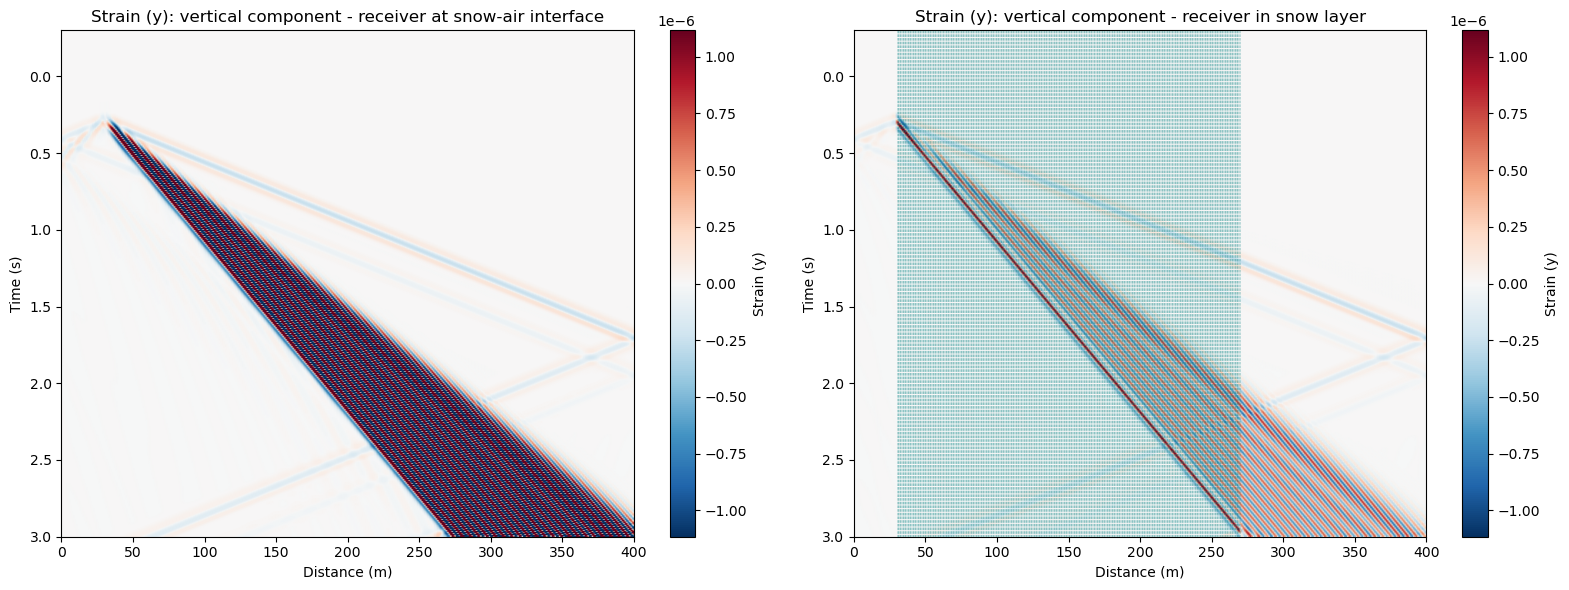

In [ ]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 1.5
y_surface_2 = 2.5

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Strain (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Strain (y): vertical component - receiver in snow layer")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)


In [ ]:
# Plotting displacement and strain next to each other
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 1.5

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_dis_y = dis_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_strain_y = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_dis_y.dims:
    sg_dis_y_plot = sg_dis_y.mean(dim=e_name)
    sg_strain_y_plot = sg_strain_y.mean(dim=e_name)
else:
    sg_dis_y_plot = sg_dis_y
    sg_strain_y_plot = sg_strain_y

# Ensure plotting order is (time, x)
sg_dis_y_plot = sg_dis_y_plot.transpose(t_name, x_name)
sg_strain_y_plot = sg_strain_y_plot.transpose(t_name, x_name)

t_vals = sg_dis_y_plot[t_name].values
x_line = sg_dis_y_plot[x_name].values
data_vx = sg_dis_y_plot.values
data_vy = sg_strain_y_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Displacement (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vx, ax=axes[0], label="Displacement (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Spatial derivative of displacement:Strain (y): vertical component - receiver at snow-air interface")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)




# Plotting x-component displacement and strain next to each other
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 1.5

# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select x-components at y receiver line
sg_dis_x = dis_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_strain_x = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_dis_x.dims:
    sg_dis_x_plot = sg_dis_x.mean(dim=e_name)
    sg_strain_x_plot = sg_strain_x.mean(dim=e_name)
else:
    sg_dis_x_plot = sg_dis_x
    sg_strain_x_plot = sg_strain_x

# Ensure plotting order is (time, x)
sg_dis_x_plot = sg_dis_x_plot.transpose(t_name, x_name)
sg_strain_x_plot = sg_strain_x_plot.transpose(t_name, x_name)

t_vals = sg_dis_x_plot[t_name].values
x_line = sg_dis_x_plot[x_name].values
data_dis_x = sg_dis_x_plot.values
data_strain_x = sg_strain_x_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("displacement x shape:", data_dis_x.shape)
print("strain x shape:", data_strain_x.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_dis_x, data_strain_x]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot displacement x (horizontal component)
im_dis_x = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_dis_x,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Displacement (x): horizontal component - receiver at snow-air interface")
plt.colorbar(im_dis_x, ax=axes[0], label="Displacement (x)")

# Plot strain x (horizontal component)
im_strain_x = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_strain_x,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Spatial derivative of displacement: Strain (x): horizontal component - receiver at snow-air interface")
plt.colorbar(im_strain_x, ax=axes[1], label="Strain (x)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)




NameError: name 'vel_2d_layered' is not defined

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.0000000000000004
data shape: (6601, 401)


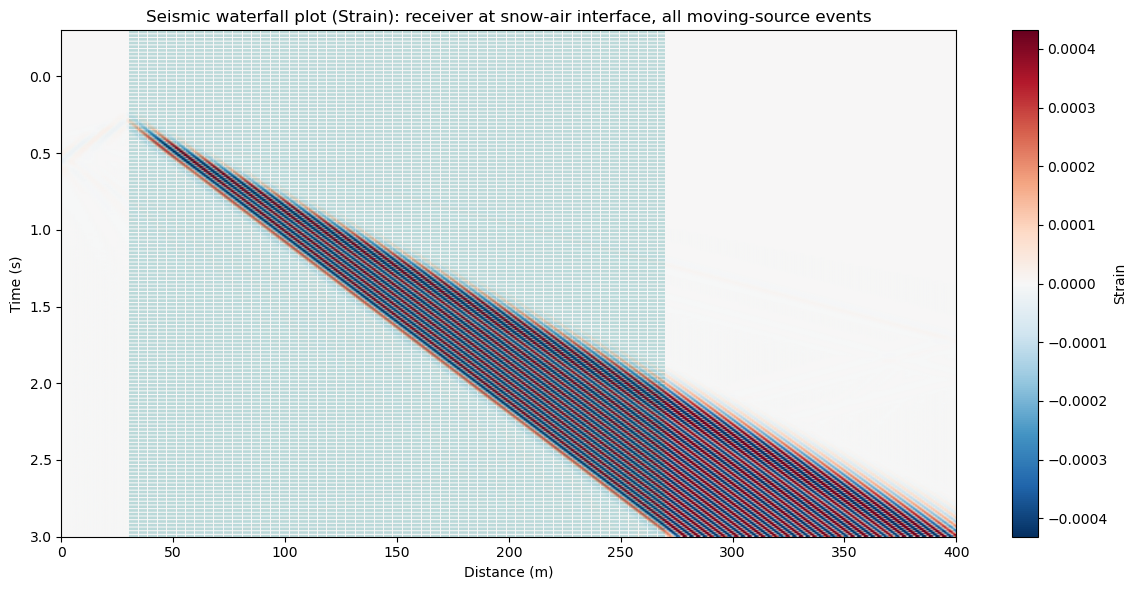

In [ ]:
# plotting other components of field
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 1.5

# vel_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select vertical component (vy), then nearest y receiver line
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest") # same for vx 

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vy.dims:
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vy_plot[t_name].values
x_line = sg_vy_plot[x_name].values
data = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line,
    t_vals,
    data,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax.invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    ax.axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 400)
ax.set_title("Seismic waterfall plot (Strain): receiver at snow-air interface, all moving-source events")
plt.colorbar(im, ax=ax, label="Strain")
plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [ ]:
# Build a combined field across all events, matching the waterfall plot logic.
vy_event = vel_2d_layered.isel({c_name: 1})
if e_name is not None and e_name in vy_event.dims:
    vy_event = vy_event.mean(dim=e_name)

# Extract raw coordinates and data the same way as static source
# vy_event dims should be (t, y, x) after transpose
vy_event = vy_event.transpose(t_name, y_name, x_name)

x_vals = vy_event[x_name].values
y_vals = vy_event[y_name].values
t_vals = vy_event[t_name].values
frames_3d = np.asarray(vy_event.values, dtype=np.float64)
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Time subsampling starting from t=0
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 1
t_idx = np.arange(t_start_idx, frames_3d.shape[0], N)

# Robust SymLogNorm scaling — same as static source
warmup = max(1, len(frames_3d) // 4)
abs_vals = np.abs(frames_3d[warmup:]).ravel()
abs_vals = abs_vals[np.isfinite(abs_vals)]
abs_vals = abs_vals[abs_vals > 1e-14]

if abs_vals.size == 0:
    vmax = 1e-8
    linthresh = 1e-10
else:
    vmax = float(np.percentile(abs_vals, 99.5))
    vmax = max(vmax, 1e-8)
    linthresh = max(float(np.percentile(abs_vals, 70)), vmax * 1e-3, 1e-10)

print("representative_event: combined over all events")
print(f"t range:        {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim: {len(t_idx)}")
print(f"vmax={vmax:.3e}, linthresh={linthresh:.3e}")


def run_animation():
    try:
        from matplotlib import colors
        from matplotlib import ticker

        norm = colors.SymLogNorm(
            linthresh=linthresh,
            vmin=-vmax,
            vmax=vmax,
            base=10,
        )

        # Avoid mathtext parsing issues in tick labels (especially with SymLog colorbar).
        plt.rcParams["axes.formatter.use_mathtext"] = False

        fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

        im = ax.imshow(
            frames_3d[t_idx[0]],
            extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="upper",
            interpolation="bilinear",
        )

        # Two-layer setup: snow over air.
        ax.axhline(1.5, color="black", lw=1.2, linestyle="--", label="snow-air interface (1.5 m)")

        ax.set_xlabel("x (m)")
        ax.set_ylabel("Depth (m)")
        ax.set_xlim(x_vals.min(), x_vals.max())
        ax.set_ylim(y_vals.max(), y_vals.min())
        ax.legend(loc="upper right", fontsize=8)
        cbar = plt.colorbar(im, ax=ax, label="Strain", shrink=0.8)
        cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1e}")
        cbar.update_ticks()
        title = ax.set_title(f"Wavefield Strain (all events combined) - t = {t_vals[t_idx[0]]:.4f} s")

        def update(frame_idx):
            ti = t_idx[frame_idx]
            im.set_data(frames_3d[ti])
            title.set_text(f"Wavefield Strain (all events combined) - t = {t_vals[ti]:.4f} s")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(t_idx),
            interval=120,
            blit=False,  # False for Pillow compatibility
        )

        if animation.writers.is_available("ffmpeg"):
            print("Saving with ffmpeg...", flush=True)
            writer = animation.FFMpegWriter(
                fps=30, codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            output_name = "wavefield_2d_moving.mp4"
        else:
            print("Saving GIF with pillow...", flush=True)
            writer = animation.PillowWriter(fps=10)
            output_name = "wavefield_2d_moving_slight_subrayleigh_vec_x.gif"

        ani.save(
            output_name,
            writer=writer,
            dpi=120,
            progress_callback=lambda i, n: print(
                f"  saving frame {i}/{n}", flush=True
            ) if i % 50 == 0 else None,
        )
        plt.close(fig)
        print(f"Done! Saved as {output_name}", flush=True)
    except Exception as exc:
        import traceback
        print(f"Animation failed: {exc}", flush=True)
        traceback.print_exc()


thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")

representative_event: combined over all events
t range:        -0.300 -> 3.000 s
frames to anim: 6001
vmax=6.469e-04, linthresh=3.318e-06
Animation running in background thread.
Check progress with: thread.is_alive()


Saving GIF with pillow...
  saving frame 0/6001


Sampling frequency: 2000.0 Hz
Nyquist frequency:  1000.0 Hz
t_vals[0]=-0.3000  t_vals[-1]=1.9995  n=4600


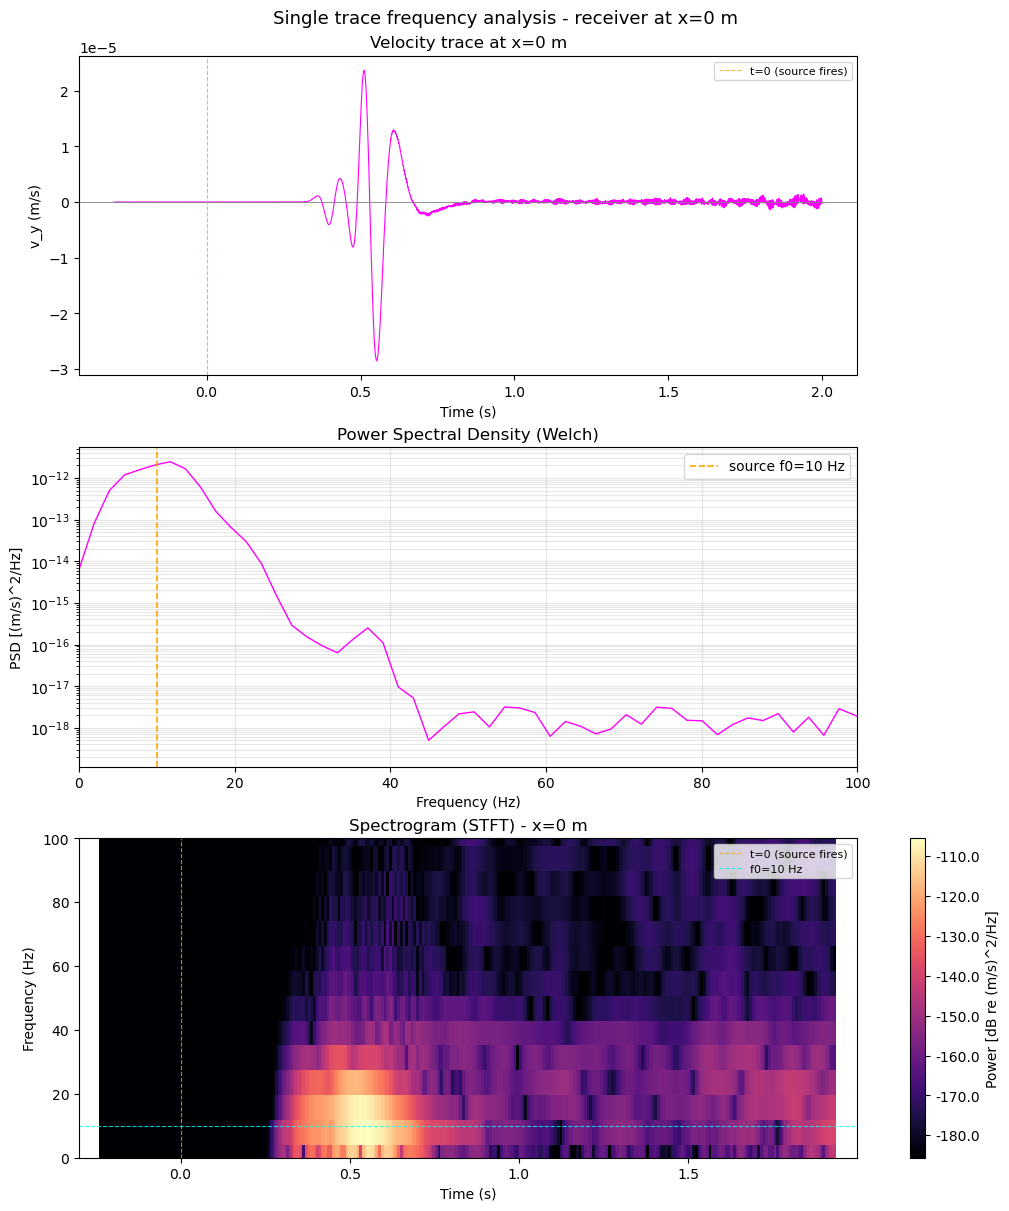

In [ ]:
# Extract a single receiver trace for frequency analysis.
from matplotlib import ticker

# Disable mathtext tick-label rendering to avoid parser crashes with Agg backend.
plt.rcParams["axes.formatter.use_mathtext"] = False
plt.rcParams["text.usetex"] = False

trace_source = sg_vy
if "event_index" in trace_source.dims:
    representative_event = int(np.argmin(np.abs(x_positions - 0.0)))
    trace_source = trace_source.isel(event_index=representative_event)

trace_dim = next((d for d in ["x", "point"] if d in trace_source.dims), None)
if trace_dim is None:
    raise ValueError(f"Could not find a receiver coordinate in dims={trace_source.dims}")

# FIX 1: slice from -0.3 to capture pre-signal and align t=0 correctly
trace = trace_source.sel({trace_dim: 0.0}, method="nearest").sel(t=slice(-0.3, 2.0))
t_vals = trace.t.values
y_vals = trace.values

dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")
print(f"t_vals[0]={t_vals[0]:.4f}  t_vals[-1]={t_vals[-1]:.4f}  n={len(t_vals)}")

fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)

# 1) Raw signed velocity trace
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].axhline(0, color="gray", lw=0.6)
# FIX 2: mark t=0 (source fires) on the trace too
axes[0].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8, label="t=0 (source fires)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("v_y (m/s)")
axes[0].set_title("Velocity trace at x=0 m")
axes[0].legend(fontsize=8)

# 2) Power Spectral Density (Welch)
nperseg = min(1024, len(y_vals) // 4)
freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1].semilogy(freqs_psd, psd, color="magenta", lw=1.0)
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, min(100, fs / 2))
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) Spectrogram (STFT)
nperseg_stft = min(256, len(y_vals) // 16)
nperseg_stft = max(nperseg_stft, int(fs * 0.05))  # at least 50ms window

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 15 // 16,
    window="hann",
    scaling="density",
)

# FIX 3: shift t_stft by the actual trace start (now -0.3s, not 0.0)
t_stft = t_stft + t_vals[0]

Sxx_db = 10 * np.log10(Sxx + 1e-40)
vmax = Sxx_db.max()
vmin = vmax - 80  # 80 dB dynamic range

im = axes[2].pcolormesh(
    t_stft,
    freqs_stft,
    Sxx_db,
    shading="auto",
    cmap="magma",
    vmin=vmin,
    vmax=vmax,
)
axes[2].set_xlim(t_vals[0], t_vals[-1])
# FIX 4: axvline at t=0 (source fires), not at t_vals[0]
axes[2].axvline(0, color="orange", lw=0.8, linestyle="--", alpha=0.8, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.8, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
cbar = fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")
cbar.formatter = ticker.FuncFormatter(lambda val, pos: f"{val:.1f}")
cbar.update_ticks()

# Apply plain scalar formatters only where axes are linear.
scalar_fmt = ticker.ScalarFormatter(useMathText=False)
scalar_fmt.set_scientific(False)
axes[0].xaxis.set_major_formatter(scalar_fmt)
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
axes[2].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))
axes[2].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=False))

plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)

from IPython.display import display
display(fig)
plt.close(fig)

In [ ]:
# Inspect files for the combined one-event output directory.
from pathlib import Path

sim_name = moving_source_simulation_name
event_name = moving_source_event_name
out_dir = Path(moving_source_output_folder)
print("Inspecting:", out_dir)

if out_dir.exists():
    files = sorted(p.relative_to(out_dir).as_posix() for p in out_dir.rglob("*"))
    print(f"Found {len(files)} files under output directory.")
    print("First 20 files:")
    for f in files[:20]:
        print(" -", f)
else:
    print("Output directory does not exist yet. Run the launch cell first.")

Inspecting: simulation_wavefield_moving_source_like_czm_subrayleigh/custom_job_moving_source_all_sources
Found 7 files under output directory.
First 20 files:
 - job_info.json
 - meta.json
 - progress.json
 - stderr
 - stdout
 - volume_data_output.h5
 - volume_data_output_elastic_volume.xdmf


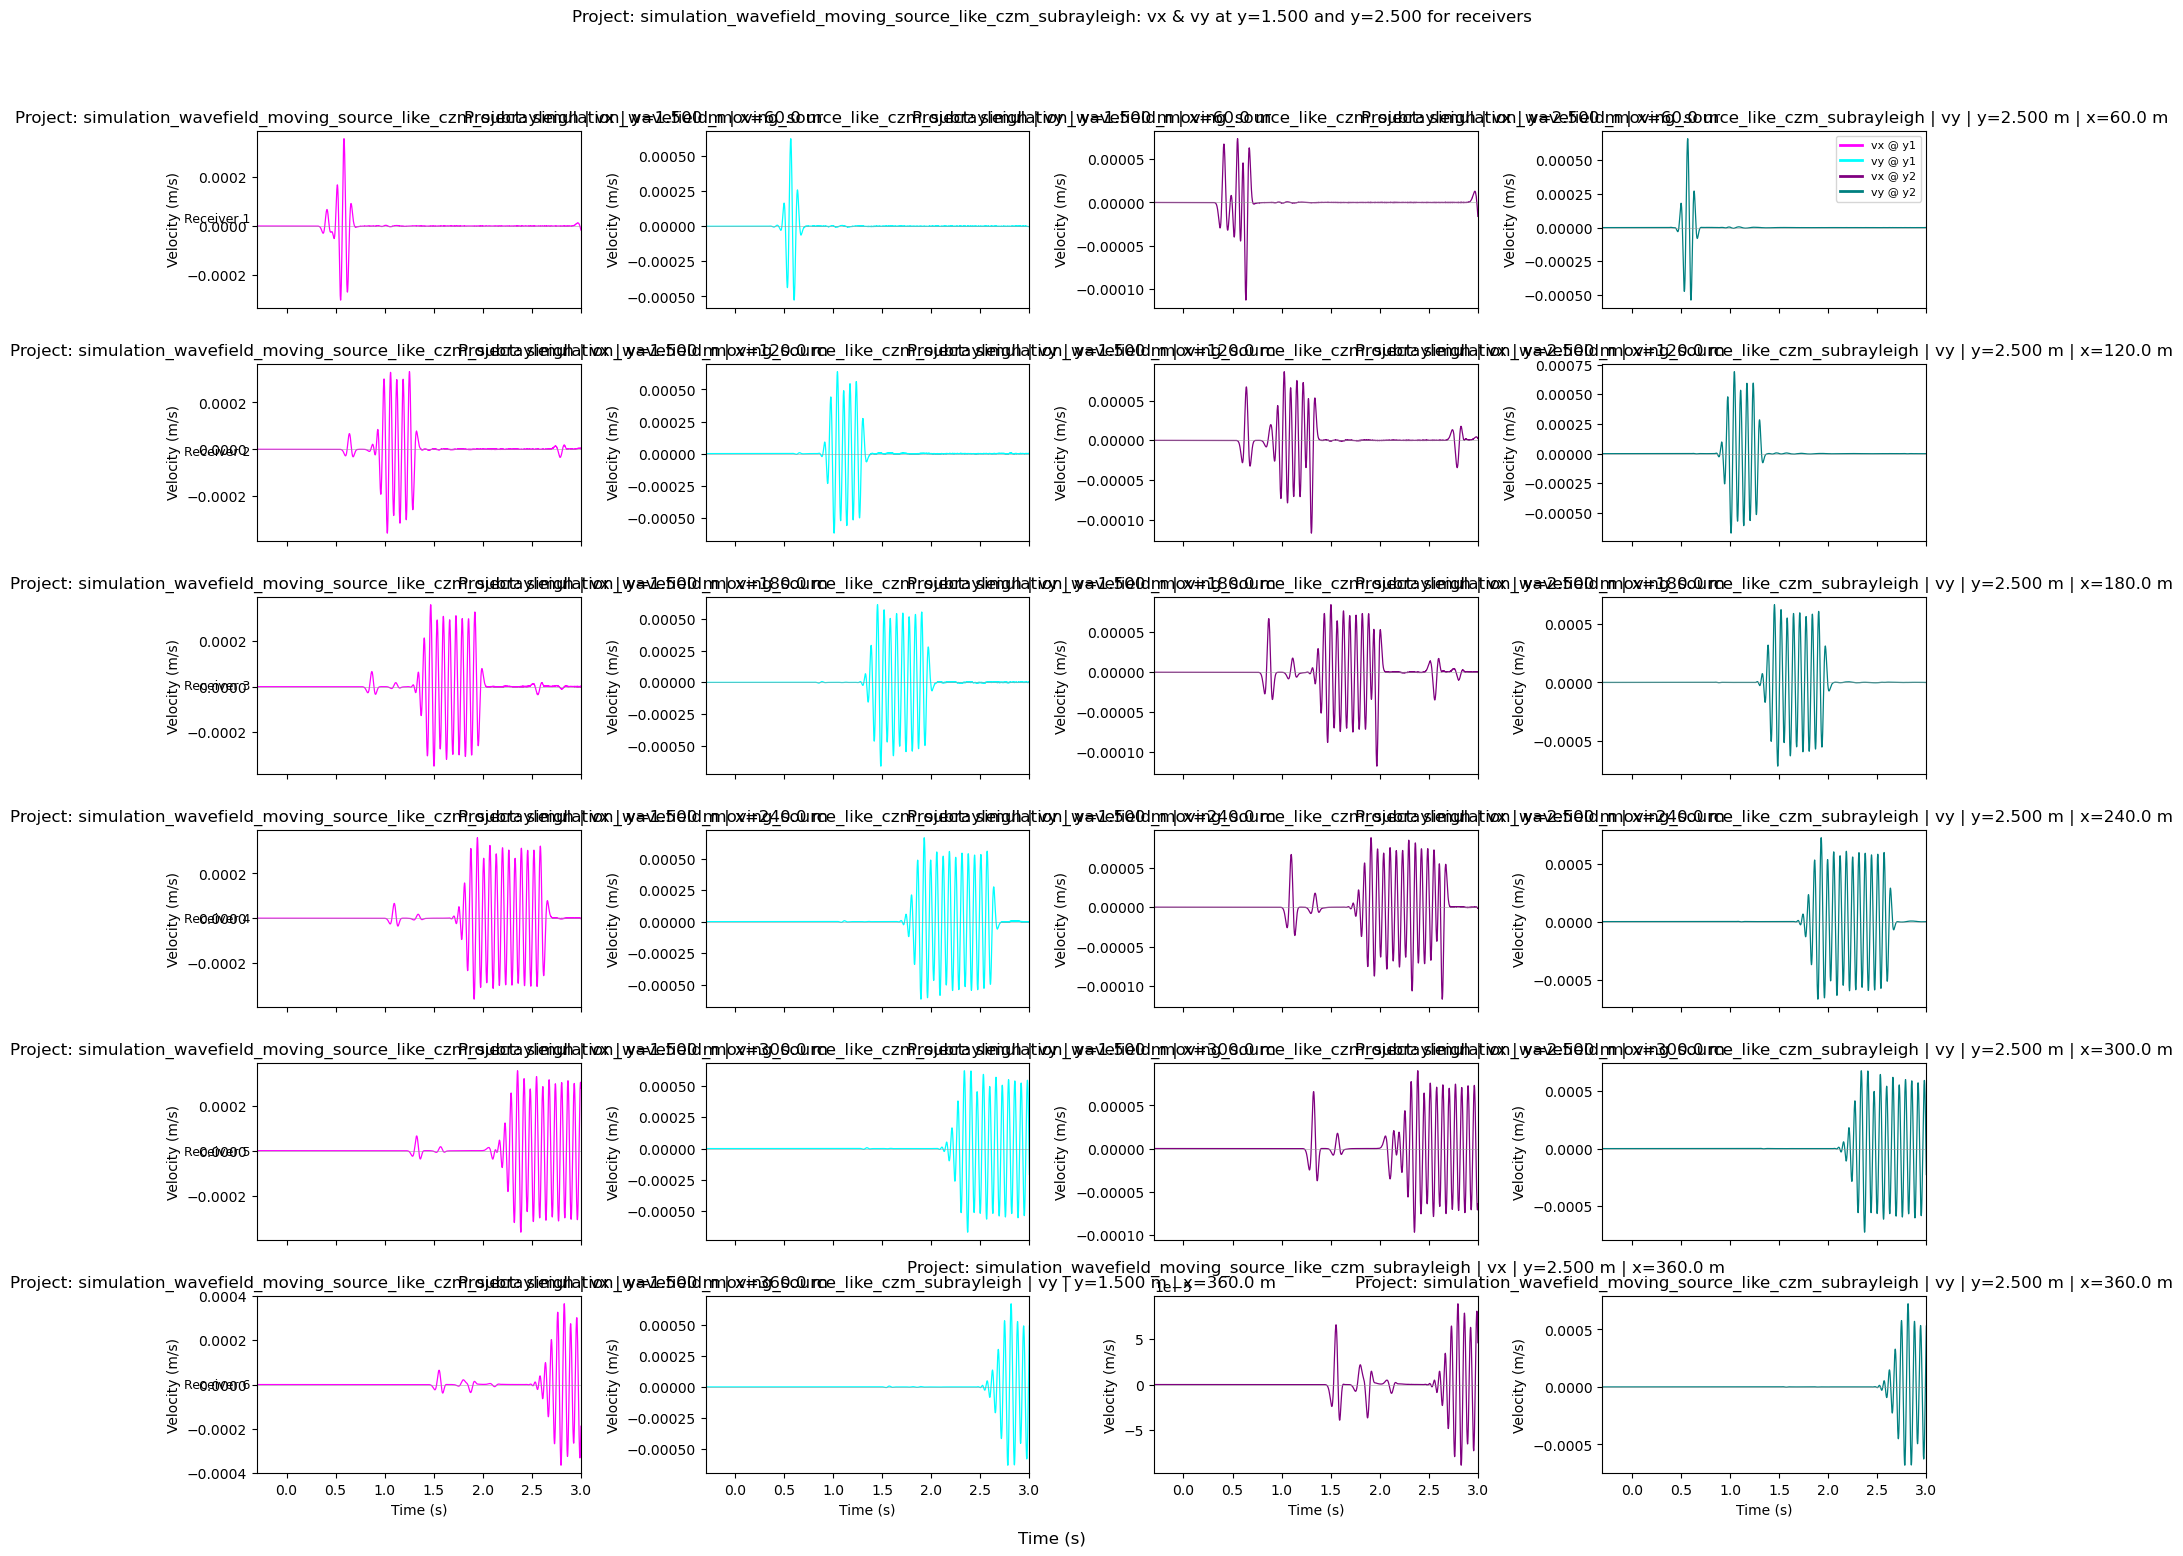

Plotted receiver traces derived from velocity field in project: simulation_wavefield_moving_source_like_czm_subrayleigh


In [ ]:
# Plotting traces at different locations for the current notebook project only
from IPython.display import display
from matplotlib.lines import Line2D
import warnings

# Receiver depths (defaults fall back to values used elsewhere)
y_surface_1 = globals().get('y_surface_1', 1.5)
y_surface_2 = globals().get('y_surface_2', 2.625)

def _receiver_line_section(data_array, receiver_y, component_index=0):
    coords_set = set(data_array.coords)
    dims_set = set(data_array.dims)

    x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
    y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
    t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
    c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
    e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

    if x_name is None or y_name is None or t_name is None or c_name is None:
        raise ValueError(
            f"Could not resolve required dimensions. Found dims={data_array.dims}, coords={list(data_array.coords)}"
        )

    section = data_array.isel({c_name: component_index}).sel({y_name: receiver_y}, method="nearest")
    if e_name is not None and e_name in section.dims:
        section = section.mean(dim=e_name)

    section = section.transpose(t_name, x_name)
    return section, x_name, t_name

# Use the velocity field already present in this notebook (vel_2d_layered).
if 'vel_2d_layered' not in globals():
    raise RuntimeError("Velocity field 'vel_2d_layered' not found in this notebook. Run the volume-load cells first.")
vel_field = globals()['vel_2d_layered']

# Build receiver x-grid and targets from this project's velocity field
example_section, x_name, t_name = _receiver_line_section(vel_field, y_surface_1, component_index=0)
x_grid = np.asarray(example_section[x_name].values, dtype=float)
channel_targets = np.quantile(x_grid, [0.15, 0.30, 0.45, 0.60, 0.75, 0.90])
channel_names = [f"Receiver {i+1}" for i in range(len(channel_targets))]

# Color map for the traces
color_map = {
    ('vx', 'y1'): 'magenta',
    ('vy', 'y1'): 'cyan',
    ('vx', 'y2'): 'purple',
    ('vy', 'y2'): 'teal',
}

def plot_case_all_receivers(vel_field, case_label):
    sections = {}
    for comp_idx, comp_name in [(0, 'vx'), (1, 'vy')]:
        sec1, x_name_loc, t_name_loc = _receiver_line_section(vel_field, y_surface_1, component_index=comp_idx)
        sec2, _, _ = _receiver_line_section(vel_field, y_surface_2, component_index=comp_idx)
        sections[(comp_name, 'y1')] = (sec1, x_name_loc, t_name_loc)
        sections[(comp_name, 'y2')] = (sec2, x_name_loc, t_name_loc)

    n_receivers = len(channel_targets)
    fig, axes = plt.subplots(n_receivers, 4, figsize=(18, 2.6 * n_receivers), sharex='col')
    if n_receivers == 1:
        axes = axes.reshape(1, 4)

    for row_idx, (x_target, rname) in enumerate(zip(channel_targets, channel_names)):
        for col_idx, (comp, depth_tag) in enumerate([('vx','y1'), ('vy','y1'), ('vx','y2'), ('vy','y2')]):
            section, x_name_loc, t_name_loc = sections[(comp, depth_tag)]
            x_vals = np.asarray(section[x_name_loc].values, dtype=float)
            idx = int(np.argmin(np.abs(x_vals - float(x_target))))
            trace = section.isel({x_name_loc: idx})
            ax = axes[row_idx, col_idx]
            color = color_map[(comp, depth_tag)]
            ax.plot(trace[t_name_loc].values, trace.values, lw=0.9, color=color, label=f"{comp}@{depth_tag}")
            ax.axhline(0.0, color='0.6', lw=0.6, alpha=0.6)
            ax.set_xlim(trace[t_name_loc].values[0], trace[t_name_loc].values[-1])

            if row_idx == n_receivers - 1:
                ax.set_xlabel('Time (s)')
            ax.set_ylabel('Velocity (m/s)')

            receiver_y = y_surface_1 if depth_tag == 'y1' else y_surface_2
            ax.set_title(f"{case_label} | {comp} | y={receiver_y:.3f} m | x={float(x_target):.1f} m")

            if col_idx == 0:
                ax.text(-0.02, 0.5, f"{rname}", transform=ax.transAxes, va='center', ha='right', fontsize=9)

    legend_handles = [Line2D([0], [0], color=color_map[('vx','y1')], lw=2, label='vx @ y1'),
                      Line2D([0], [0], color=color_map[('vy','y1')], lw=2, label='vy @ y1'),
                      Line2D([0], [0], color=color_map[('vx','y2')], lw=2, label='vx @ y2'),
                      Line2D([0], [0], color=color_map[('vy','y2')], lw=2, label='vy @ y2')]
    axes[0, -1].legend(handles=legend_handles, loc='upper right', fontsize=8)

    fig.supxlabel('Time (s)', fontsize=12)
    fig.suptitle(f"{case_label}: vx & vy at y={y_surface_1:.3f} and y={y_surface_2:.3f} for receivers", y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    display(fig)
    plt.close(fig)

# Plot only for this notebook's project
project_label = globals().get('PROJECT_DIR', 'this_notebook_project')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    plot_case_all_receivers(vel_field, f"Project: {project_label}")

print(f"Plotted receiver traces derived from velocity field in project: {project_label}")

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.3 -> 3.0000000000000004
vx shape: (6601, 401)
vy shape: (6601, 401)


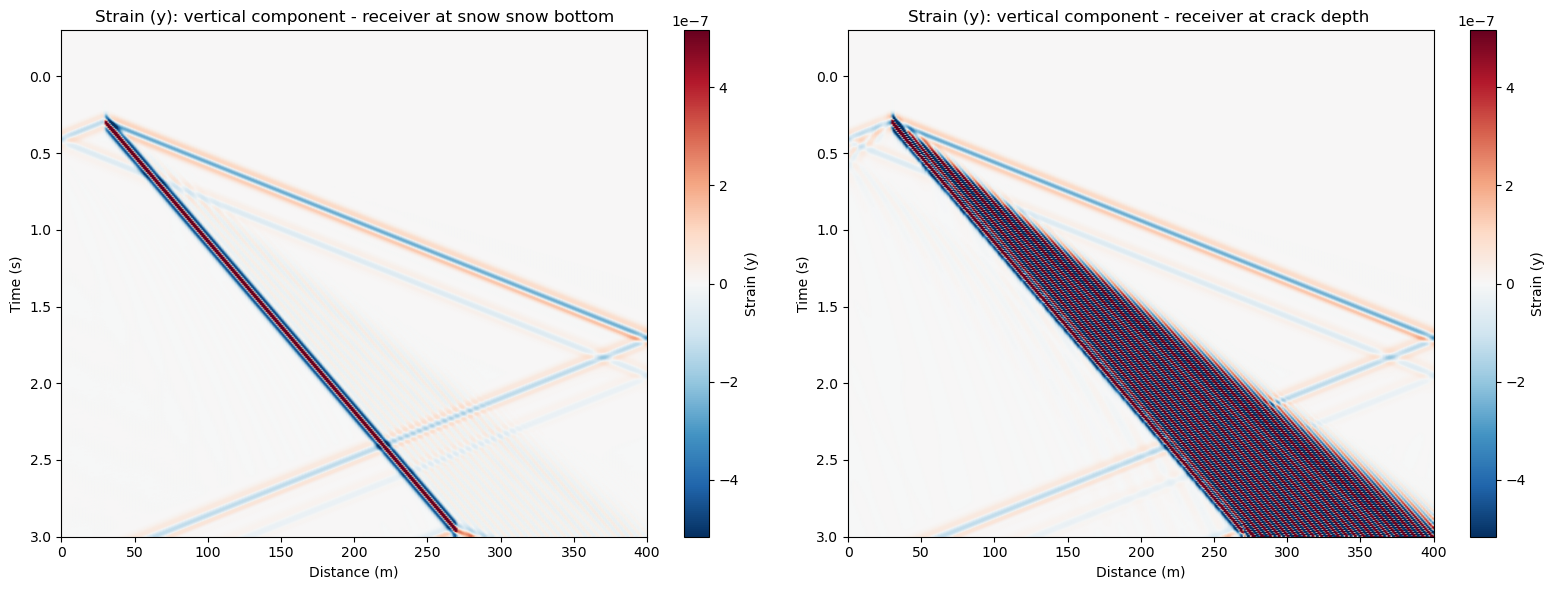

  saving frame 50/6001
  saving frame 100/6001
  saving frame 150/6001
  saving frame 200/6001
  saving frame 250/6001
  saving frame 300/6001
  saving frame 350/6001
  saving frame 400/6001
  saving frame 450/6001
  saving frame 500/6001
  saving frame 550/6001
  saving frame 600/6001
  saving frame 650/6001
  saving frame 700/6001
  saving frame 750/6001
  saving frame 800/6001
  saving frame 850/6001
  saving frame 900/6001
  saving frame 950/6001
  saving frame 1000/6001
  saving frame 1050/6001
  saving frame 1100/6001
  saving frame 1150/6001
  saving frame 1200/6001
  saving frame 1250/6001
  saving frame 1300/6001
  saving frame 1350/6001
  saving frame 1400/6001
  saving frame 1450/6001
  saving frame 1500/6001
  saving frame 1550/6001


In [ ]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 2.25
y_surface_2 = 2.625

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Strain (y): vertical component - receiver at snow snow bottom")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Strain (y): vertical component - receiver at crack depth ")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)
